In [3]:
import shap
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.calibration import CalibratedClassifierCV
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [7]:
df = pd.read_csv("very_final_dataset.csv")
df = df[df['position'] != 'G']
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Define the Preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        # handle_unknown='ignore' prevents errors if a new category appears in the test set
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), [0])
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

# Define the Base Model
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

# Bind them together in a Pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', xgb)
])

                    Feature  Importance
12   last15_shots_top_third    0.039599
20  cumul_shots_under_press    0.039947
1                position_D    0.042631
16     cumul_mean_max_speed    0.042758
27      cumul_average_angle    0.044202
17         cumul_peak_speed    0.044592
21    cumul_shots_top_third    0.050275
25    cumul_action_accuracy    0.058028
14                cumul_hsr    0.067479
0                position_A    0.089321


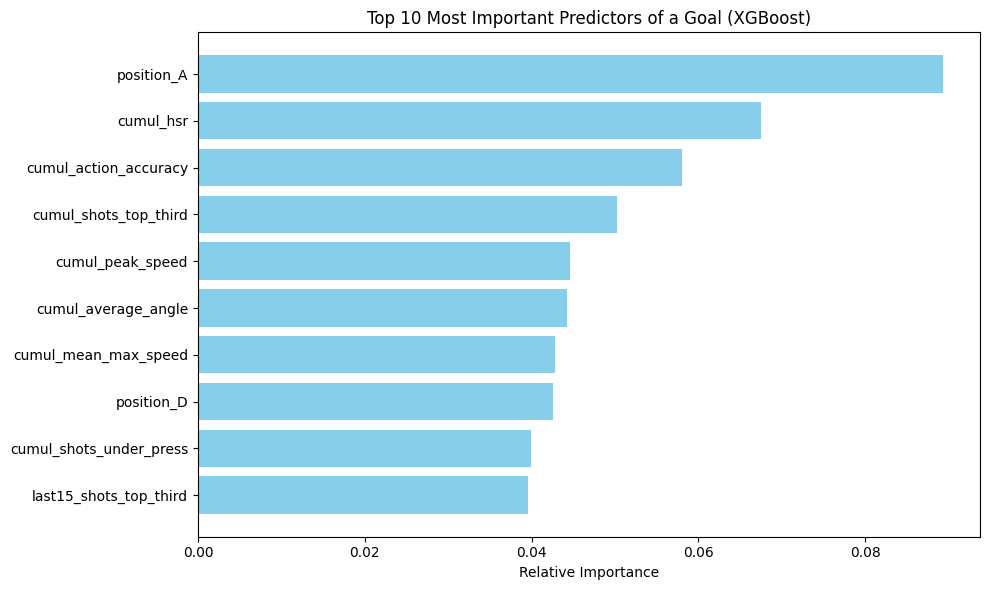

In [8]:
# Get the feature importances
model_pipeline.fit(X_train, y_train)

# Extract the preprocessor and the XGBoost model from your pipeline
preprocessor = model_pipeline.named_steps['preprocessor']
xgb_model = model_pipeline.named_steps['classifier']

# Get the feature importances
importances = xgb_model.feature_importances_

# Get the updated feature names directly from the preprocessor
feature_names = preprocessor.get_feature_names_out()

# Create a DataFrame for easy sorting
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort and display the top 10 most important features
importance_df = importance_df.sort_values(by='Importance', ascending=True).tail(10)
print(importance_df)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.title('Top 10 Most Important Predictors of a Goal (XGBoost)')
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')

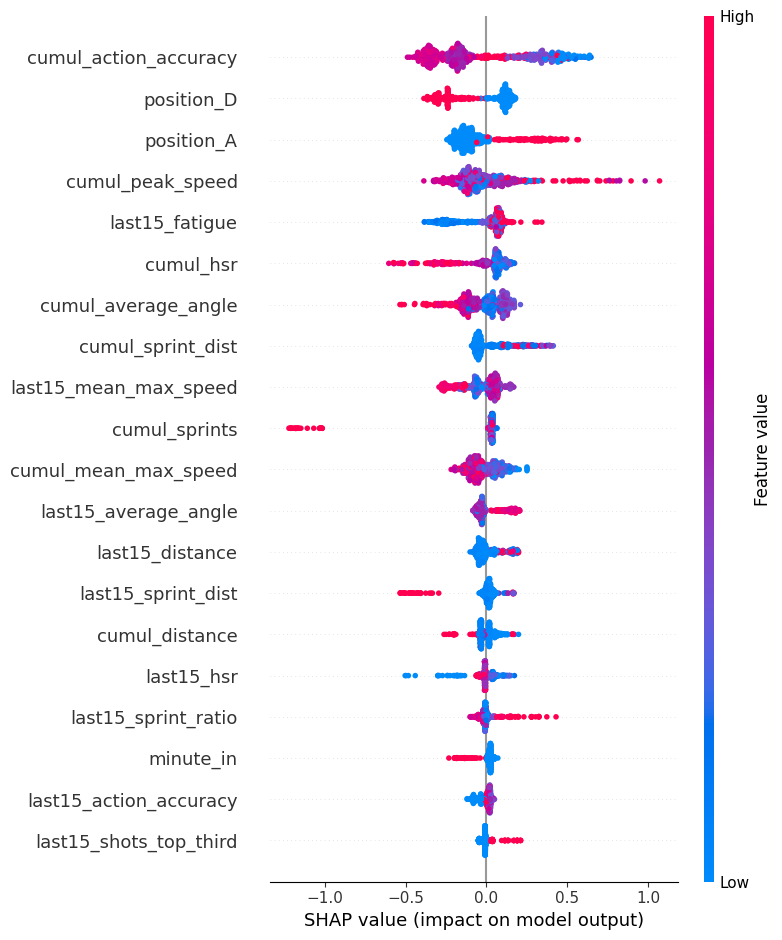

In [9]:
# Initialize the SHAP explainer on your trained XGBoost model
explainer = shap.TreeExplainer(xgb_model)

# Calculate SHAP values for your test set
X_test_transformed = preprocessor.transform(X_test)
shap_values = explainer.shap_values(X_test_transformed)

# Plot the summary
shap.summary_plot(shap_values, X_test_transformed, feature_names=feature_names)